In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv('train.csv')
df.sample(n=5)

,x,y
223,53.0,57.111951
57,69.0,62.649317
261,49.0,49.723590
447,25.0,25.537528
355,51.0,50.512346


In [8]:
x = df[['x']]
y = df['y']


In [9]:
y.isna()

0      False
1      False
2      False
3      False
4      False
       ...  
695    False
696    False
697    False
698    False
699    False
Name: y, Length: 700, dtype: bool

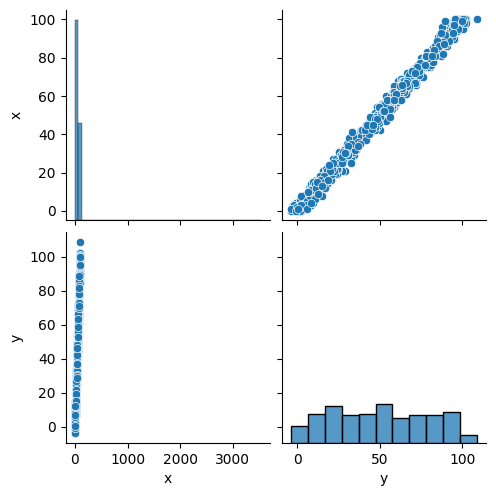

In [10]:
import seaborn as sns
sns.pairplot(df)

In [11]:
class LinearRegression:
    def __init__(self, learning_rate=0.001, n_iter=100):
        self.learning_rate = learning_rate  
        self.n_iter = n_iter
        self.w = None
        self.b = None
        self.losses = []

    def fit(self, x, y):
        n_samples, n_features = x.shape

        # Initialize weights to zero
        self.w = np.zeros(n_features)
        self.b = 0
        
        # Ensure y is a flat numpy array
        y = np.asarray(y).flatten()

        for epoch in range(self.n_iter):
            # Forward pass
            y_pred = np.dot(x, self.w) + self.b

            # Compute loss
            error = y_pred - y
            mse_loss = np.mean(error ** 2)
            self.losses.append(mse_loss)

            # Compute gradients
            dw = (2.0 / n_samples) * np.dot(x.T, error)
            db = (2.0 / n_samples) * np.sum(error)

            # Update weights and bias  
            self.w = self.w - self.learning_rate * dw
            self.b = self.b - self.learning_rate * db

    def predict(self, x):
        x = np.asarray(x)
        return np.dot(x, self.w) + self.b
    
    def get_losses(self):
        return self.losses

In [12]:
def mean_squared_error(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    return np.mean((y_true - y_pred) ** 2)

def r2_score(y_true, y_pred):
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    rss = np.sum((y_true - y_pred) ** 2)
    tss = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (rss / tss)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Convert to numpy arrays
x_train = np.array(x_train)
x_test = np.array(x_test)
y_train = np.array(y_train).flatten()
y_test = np.array(y_test).flatten()

# Check for NaN values
print(f"NaN in x_train: {np.isnan(x_train).sum()}")
print(f"NaN in y_train: {np.isnan(y_train).sum()}")

# Remove rows with NaN
valid_idx = ~(np.isnan(x_train).any(axis=1) | np.isnan(y_train))
x_train = x_train[valid_idx]
y_train = y_train[valid_idx]

# Feature scaling (important for gradient descent)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")

NaN in x_train: 0
NaN in y_train: 1
x_train shape: (559, 1), y_train shape: (559,)


In [14]:
model = LinearRegression(learning_rate=0.01, n_iter=1000)

model.fit(x_train, y_train)
y_pred = model.predict(x_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R2 Score: {r2}')


Mean Squared Error: 8.00275015524171
R2 Score: 0.9915274167846608


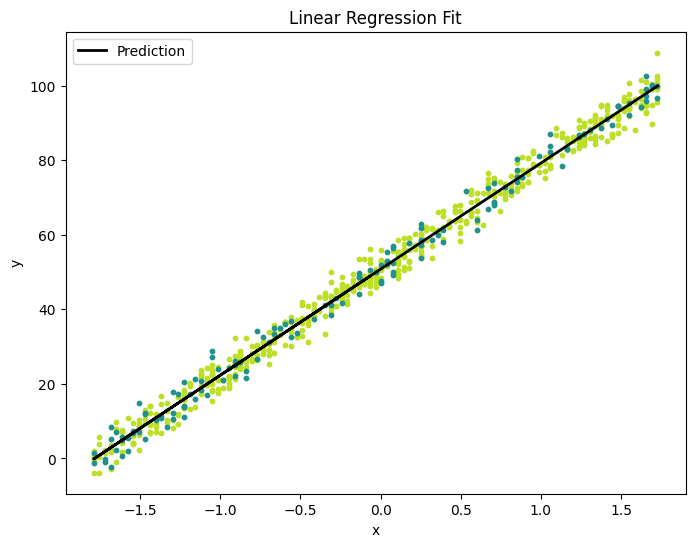

In [15]:
cmap = plt.get_cmap("viridis")
plt.figure(figsize=(8, 6))
plt.scatter(x_train, y_train, color=cmap(0.9), s=10)
plt.scatter(x_test, y_test, color=cmap(0.5), s=10)
plt.plot(x_test, y_pred, color="black", linewidth=2, label="Prediction")
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression Fit')
plt.legend()
plt.show()


In [17]:
class MultiLinearRegression:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        n, m = X.shape
        self.w = np.zeros(m)
        self.b = 0

        for _ in range(self.epochs):
            y_pred = X @ self.w + self.b
            error = y_pred - y

            self.w -= self.lr * (2/n) * (X.T @ error)
            self.b -= self.lr * (2/n) * np.sum(error)

    def predict(self, X):
        return X @ self.w + self.b

In [24]:
df2 = pd.read_csv('50_Startups.csv')
df2.sample(n=5)

,R&D Spend,Administration,Marketing Spend,State,Profit
29,65605.48,153032.06,107138.38,New York,101004.64
4,142107.34,91391.77,366168.42,Florida,166187.94
6,134615.46,147198.87,127716.82,California,156122.51
40,28754.33,118546.05,172795.67,California,78239.91
18,91749.16,114175.79,294919.57,Florida,124266.90


In [ ]:


numeric_cols = df2.select_dtypes(include=[np.number]).columns.tolist()
X = df2[numeric_cols[:-1]].values  # All numeric columns except target
y = df2[numeric_cols[-1]].values   # Last numeric column is target

# Split data
X_train, X_test, y_train_mlr, y_test_mlr = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature scaling
scaler_mlr = StandardScaler()
X_train = scaler_mlr.fit_transform(X_train)
X_test = scaler_mlr.transform(X_test)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train_mlr.shape}")
print(f"Features: {numeric_cols[:-1]}, Target: {numeric_cols[-1]}")


X_train shape: (40, 3), y_train shape: (40,)
Features: ['R&D Spend', 'Administration', 'Marketing Spend'], Target: Profit


In [30]:

# Train MultiLinear Regression using the existing LinearRegression class
model_mlr = MultiLinearRegression()
model_mlr.fit(X_train, y_train_mlr)

# Make predictions
y_pred_mlr = model_mlr.predict(X_test)

# Evaluate
mse_mlr = mean_squared_error(y_test_mlr, y_pred_mlr)
r2_mlr = r2_score(y_test_mlr, y_pred_mlr)

print(f'Multiple Linear Regression Results:')
print(f'Mean Squared Error: {mse_mlr}')
print(f'R2 Score: {r2_mlr}')
print(f'\nWeights: {model_mlr.w}')
print(f'Bias: {model_mlr.b}')


Multiple Linear Regression Results:
Mean Squared Error: 81332903.49766622
R2 Score: 0.8995632259940614

Weights: [37771.19503553 -1762.20439127  3784.09175821]
Bias: 115651.72030536192


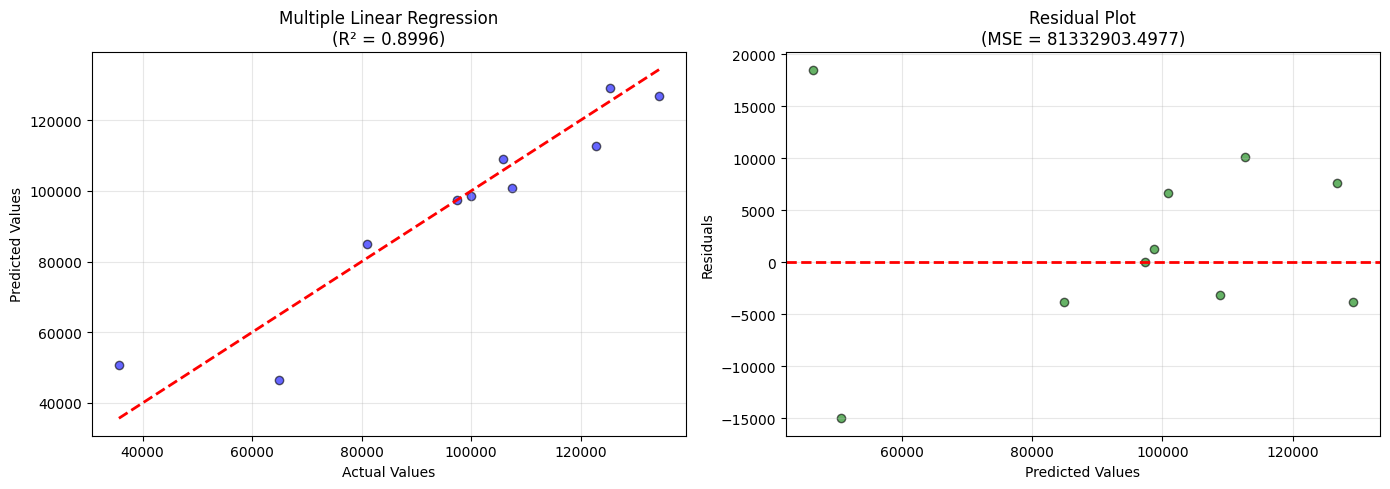

In [31]:

# Plot: Multiple Linear Regression - Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test_mlr, y_pred_mlr, alpha=0.6, color='blue', edgecolor='k')
axes[0].plot([y_test_mlr.min(), y_test_mlr.max()], [y_test_mlr.min(), y_test_mlr.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')
axes[0].set_title(f'Multiple Linear Regression\n(R² = {r2_mlr:.4f})')
axes[0].grid(True, alpha=0.3)

# Plot 2: Residuals
residuals = y_test_mlr - y_pred_mlr
axes[1].scatter(y_pred_mlr, residuals, alpha=0.6, color='green', edgecolor='k')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title(f'Residual Plot\n(MSE = {mse_mlr:.4f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
